# V-JEPA 2 Demo Notebook

This tutorial provides an example of how to load the V-JEPA 2 model in vanilla PyTorch and HuggingFace, extract a video embedding, and then predict an action class. For more details about the paper and model weights, please see https://github.com/facebookresearch/vjepa2.

First, let's import the necessary libraries and load the necessary functions for this tutorial.

In [18]:
import json
import os
import subprocess

import numpy as np
import torch
import torch.nn.functional as F
from decord import VideoReader
from transformers import AutoVideoProcessor, AutoModel

import src.datasets.utils.video.transforms as video_transforms
import src.datasets.utils.video.volume_transforms as volume_transforms
from src.models.attentive_pooler import AttentiveClassifier
from src.models.vision_transformer import vit_giant_xformers_rope

IMAGENET_DEFAULT_MEAN = (0.485, 0.456, 0.406)
IMAGENET_DEFAULT_STD = (0.229, 0.224, 0.225)

def load_pretrained_vjepa_pt_weights(model, pretrained_weights):
    # Load weights of the VJEPA2 encoder
    # The PyTorch state_dict is already preprocessed to have the right key names
    pretrained_dict = torch.load(pretrained_weights, weights_only=True, map_location="cpu")["encoder"]
    pretrained_dict = {k.replace("module.", ""): v for k, v in pretrained_dict.items()}
    pretrained_dict = {k.replace("backbone.", ""): v for k, v in pretrained_dict.items()}
    msg = model.load_state_dict(pretrained_dict, strict=False)
    print("Pretrained weights found at {} and loaded with msg: {}".format(pretrained_weights, msg))


def load_pretrained_vjepa_classifier_weights(model, pretrained_weights):
    # Load weights of the VJEPA2 classifier
    # The PyTorch state_dict is already preprocessed to have the right key names
    pretrained_dict = torch.load(pretrained_weights, weights_only=True, map_location="cpu")["classifiers"][0]
    pretrained_dict = {k.replace("module.", ""): v for k, v in pretrained_dict.items()}
    msg = model.load_state_dict(pretrained_dict, strict=False)
    print("Pretrained weights found at {} and loaded with msg: {}".format(pretrained_weights, msg))


def build_pt_video_transform(img_size):
    short_side_size = int(256.0 / 224 * img_size)
    # Eval transform has no random cropping nor flip
    eval_transform = video_transforms.Compose(
        [
            video_transforms.Resize(short_side_size, interpolation="bilinear"),
            video_transforms.CenterCrop(size=(img_size, img_size)),
            volume_transforms.ClipToTensor(),
            video_transforms.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD),
        ]
    )
    return eval_transform

In [83]:
import numpy as np
from decord import VideoReader, cpu

def inspect_video(video_path_or_s3: str, cache_dir: str = "/tmp/vjepa_s3_cache", decode_first_frame: bool = True):
    # reuse your S3->local cache helper
    if video_path_or_s3.startswith("s3://"):
        local_path = s3_to_local_cached(video_path_or_s3, cache_dir=cache_dir)
    else:
        local_path = video_path_or_s3

    vr = VideoReader(local_path, ctx=cpu(0), num_threads=2)

    n_frames = len(vr)

    fps = None
    try:
        fps = float(vr.get_avg_fps())
    except Exception:
        pass

    h = w = c = dtype = None
    if decode_first_frame:
        f0 = vr[0].asnumpy()          # H x W x C
        h, w, c = f0.shape
        dtype = str(f0.dtype)

    return {
        "local_path": local_path,
        "num_frames": n_frames,
        "avg_fps": fps,
        "frame_shape_hwc": (h, w, c) if decode_first_frame else None,
        "dtype": dtype,
    }

# Example
# info = inspect_video(video_s3_uri)
# print(info)


# Labels

In [77]:
! cat /home/sagemaker-user/user-default-efs/vjepa2/classifier/uhn_views_22k_mapping_train.txt

0	A2C
1	A3C
2	A4C
3	A5C
4	Exclude
5	PLAX
6	PSAX-AP
7	PSAX-AV
8	PSAX-MV
9	PSAX-PM
10	SSN
11	Subcostal
12	TEE


In [78]:
import argparse
import json
from pathlib import Path


def parse_mapping(path: Path) -> dict:
    mapping = {}
    for lineno, raw in enumerate(path.read_text(encoding="utf-8").splitlines(), start=1):
        line = raw.strip()
        if not line or line.startswith("#"):
            continue

        parts = line.split()
        if len(parts) < 2:
            raise ValueError(f"Line {lineno}: expected '<int> <label>', got: {raw!r}")

        idx_str = parts[0]
        label = " ".join(parts[1:])  # supports labels with spaces

        try:
            idx = int(idx_str)
        except ValueError:
            raise ValueError(f"Line {lineno}: index is not an int: {idx_str!r}")

        mapping[str(idx)] = label

    if not mapping:
        raise ValueError("No mappings parsed (file empty or all comments).")

    return mapping

In [79]:
txt_classes  = "/home/sagemaker-user/user-default-efs/vjepa2/classifier/uhn_views_22k_mapping_train.txt"
json_classes = "/home/sagemaker-user/user-default-efs/vjepa2/classifier/uhn_views_22k_mapping_train.json"

in_path = Path(txt_classes)
out_path = Path(json_classes)
mapping = parse_mapping(in_path)

out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(mapping, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")

215

In [80]:
! cat /home/sagemaker-user/user-default-efs/vjepa2/classifier/uhn_views_22k_mapping_train.json

{
  "0": "A2C",
  "1": "A3C",
  "2": "A4C",
  "3": "A5C",
  "4": "Exclude",
  "5": "PLAX",
  "6": "PSAX-AP",
  "7": "PSAX-AV",
  "8": "PSAX-MV",
  "9": "PSAX-PM",
  "10": "SSN",
  "11": "Subcostal",
  "12": "TEE"
}


# Classifier

In [74]:
# HuggingFace model repo name
hf_model_name = (
    "facebook/vjepa2-vitg-fpc64-384"  # Replace with your favored model, e.g. facebook/vjepa2-vitg-fpc64-384
)
# Path to local PyTorch weights
pt_model_path = "/home/sagemaker-user/user-default-efs/vjepa2/checkpoints/anneal/keep/pt-280-an81.pt"

# Initialize the HuggingFace model, load pretrained weights
model_hf = AutoModel.from_pretrained(hf_model_name)
model_hf.cuda().eval()

# Build HuggingFace preprocessing transform
hf_transform = AutoVideoProcessor.from_pretrained(hf_model_name)
img_size = hf_transform.crop_size["height"]  # E.g. 384, 256, etc.

# Initialize the PyTorch model, load pretrained weights
model_pt = vit_giant_xformers_rope(img_size=(img_size, img_size), num_frames=64)
model_pt.cuda().eval()
load_pretrained_vjepa_pt_weights(model_pt, pt_model_path)

### Can also use torch.hub to load the model
# model_pt, _ = torch.hub.load('facebookresearch/vjepa2', 'vjepa2_vit_giant_384')
# model_pt.cuda().eval()

# Build PyTorch preprocessing transform
pt_video_transform = build_pt_video_transform(img_size=img_size)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Pretrained weights found at /home/sagemaker-user/user-default-efs/vjepa2/checkpoints/anneal/keep/pt-280-an81.pt and loaded with msg: <All keys matched successfully>


In [75]:
def get_video(video_path_or_s3: str, cache_dir: str = "/tmp/vjepa_s3_cache"):
    # Resolve S3 -> local cached file
    if video_path_or_s3.startswith("s3://"):
        local_video = s3_to_local_cached(video_path_or_s3, cache_dir=cache_dir)
    else:
        local_video = video_path_or_s3

    # decord: decode only requested frames (efficient)
    vr = VideoReader(local_video, ctx=cpu(0), num_threads=4)

    frame_idx = np.arange(0, 128, 2)
    frame_idx = frame_idx[frame_idx < len(vr)]  # guard short videos

    video = vr.get_batch(frame_idx).asnumpy()  # T x H x W x C (uint8)
    return video

In [76]:
def forward_vjepa_video(model_hf, model_pt, hf_transform, pt_transform, video_path_or_s3):
    # Run a sample inference with VJEPA
    with torch.inference_mode():
        # Read and pre-process the image
        video = get_video(video_path_or_s3)  # T x H x W x C
        video = torch.from_numpy(video).permute(0, 3, 1, 2)  # T x C x H x W
        x_pt = pt_transform(video).cuda().unsqueeze(0)
        x_hf = hf_transform(video, return_tensors="pt")["pixel_values_videos"].to("cuda")
        # Extract the patch-wise features from the last layer
        out_patch_features_pt = model_pt(x_pt)
        out_patch_features_hf = model_hf.get_vision_features(x_hf)

    return out_patch_features_hf, out_patch_features_pt

In [81]:
def get_vjepa_video_classification_results(classifier, out_patch_features_pt):
    SOMETHING_SOMETHING_V2_CLASSES = json.load(open(json_classes, "r"))

    with torch.inference_mode():
        out_classifier = classifier(out_patch_features_pt)

    print(f"Classifier output shape: {out_classifier.shape}")

    print("Top 5 predicted class names:")
    top5_indices = out_classifier.topk(5).indices[0]
    top5_probs = F.softmax(out_classifier.topk(5).values[0]) * 100.0  # convert to percentage
    for idx, prob in zip(top5_indices, top5_probs):
        str_idx = str(idx.item())
        print(f"{SOMETHING_SOMETHING_V2_CLASSES[str_idx]} ({prob}%)")

    return

# Make Prediction

In [82]:
import os
import re
import hashlib
from pathlib import Path

import boto3
from boto3.s3.transfer import TransferConfig
import numpy as np
import torch
from decord import VideoReader, cpu

# ----------------------------
# S3 -> local cache (efficient)
# ----------------------------
_S3_RE = re.compile(r"^s3://([^/]+)/(.+)$")

def _parse_s3_uri(s3_uri: str):
    m = _S3_RE.match(s3_uri)
    if not m:
        raise ValueError(f"Not an s3:// URI: {s3_uri}")
    return m.group(1), m.group(2)

def _safe_cache_name(s3_uri: str) -> str:
    # stable name, avoids long paths and collisions
    h = hashlib.sha1(s3_uri.encode("utf-8")).hexdigest()[:16]
    base = os.path.basename(_parse_s3_uri(s3_uri)[1])
    return f"{h}__{base}"

def s3_to_local_cached(
    s3_uri: str,
    cache_dir: str = "/tmp/vjepa_s3_cache",
    requester_pays: bool = False,
    force: bool = False,
) -> str:
    """
    Download an s3:// video to a local cache if needed, then return local path.

    Efficient because:
      - uses boto3 TransferManager (multipart, parallel)
      - caches per-URI on local disk (no re-download across calls)
    """
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    local_path = cache_dir / _safe_cache_name(s3_uri)
    meta_path = local_path.with_suffix(local_path.suffix + ".meta")

    bucket, key = _parse_s3_uri(s3_uri)
    s3 = boto3.client("s3")

    extra = {"RequestPayer": "requester"} if requester_pays else {}

    # HEAD for ETag/Size to validate cache
    head = s3.head_object(Bucket=bucket, Key=key, **extra)
    etag = head.get("ETag", "").strip('"')
    size = int(head.get("ContentLength", 0))

    if not force and local_path.exists() and meta_path.exists():
        try:
            cached_etag, cached_size = meta_path.read_text().strip().split()
            if cached_etag == etag and int(cached_size) == size:
                return str(local_path)
        except Exception:
            pass  # fall through to re-download

    # Download (multipart + concurrency)
    cfg = TransferConfig(
        multipart_threshold=64 * 1024 * 1024,   # 64MB
        multipart_chunksize=64 * 1024 * 1024,   # 64MB parts
        max_concurrency=8,
        use_threads=True,
    )

    tmp_path = str(local_path) + ".partial"
    if os.path.exists(tmp_path):
        os.remove(tmp_path)

    s3.download_file(
        Bucket=bucket,
        Key=key,
        Filename=tmp_path,
        ExtraArgs=extra if extra else None,
        Config=cfg,
    )
    os.replace(tmp_path, local_path)

    meta_path.write_text(f"{etag} {size}\n")
    return str(local_path)

In [98]:
s3_root = "s3://echodata25/results/uhn_studies_22k_607_224px/"
# s3_root = "s3://echodata25/results/uhn_studies_22k_607_224px/"
video_s3_uri = s3_root + "1.2.276.0.7230010.3.1.2.845494328.1.1703601083.21554949/1.2.276.0.7230010.3.1.3.845494328.1.1703601083.21554950/1.2.276.0.7230010.3.1.4.1714512485.1.1703601339.19077229.mp4"

In [99]:
info = inspect_video(video_s3_uri)
print(info)

{'local_path': '/tmp/vjepa_s3_cache/00cbd52d860741fc__1.2.276.0.7230010.3.1.4.1714512485.1.1703601339.19077229.mp4', 'num_frames': 32, 'avg_fps': 30.0, 'frame_shape_hwc': (224, 224, 3), 'dtype': 'uint8'}


In [100]:
# Inference on video to get the patch-wise features
out_patch_features_hf, out_patch_features_pt = forward_vjepa_video(
    model_hf, model_pt, hf_transform, pt_video_transform, video_s3_uri
)

print(
    f"""
    Inference results on video:
    HuggingFace output shape: {out_patch_features_hf.shape}
    PyTorch output shape:     {out_patch_features_pt.shape}
    Absolute difference sum:  {torch.abs(out_patch_features_pt - out_patch_features_hf).sum():.6f}
    Close: {torch.allclose(out_patch_features_pt, out_patch_features_hf, atol=1e-3, rtol=1e-3)}
    """
)


    Inference results on video:
    HuggingFace output shape: torch.Size([1, 4608, 1408])
    PyTorch output shape:     torch.Size([1, 4608, 1408])
    Absolute difference sum:  16441666.000000
    Close: False
    


In [101]:
# Initialize the classifier
classifier_model_path = "evals/vitg-384/classifier/video_classification_frozen/uhn22k-classifier-fs2-ns2-nvs1-echojepa/epoch_030.pt"
classifier = (
    AttentiveClassifier(embed_dim=model_pt.embed_dim, num_heads=16, depth=1, num_classes=13).cuda().eval()
)
load_pretrained_vjepa_classifier_weights(classifier, classifier_model_path)

# Get classification results
get_vjepa_video_classification_results(classifier, out_patch_features_pt)

Pretrained weights found at evals/vitg-384/classifier/video_classification_frozen/uhn22k-classifier-fs2-ns2-nvs1-echojepa/epoch_030.pt and loaded with msg: <All keys matched successfully>
Classifier output shape: torch.Size([1, 13])
Top 5 predicted class names:
PSAX-PM (50.00324249267578%)
PSAX-MV (49.4925651550293%)
PSAX-AP (0.44679129123687744%)
PSAX-AV (0.0461922362446785%)
Exclude (0.0112138781696558%)


/tmp/ipykernel_7278/2430421827.py:11: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  top5_probs = F.softmax(out_classifier.topk(5).values[0]) * 100.0  # convert to percentage


# Batch Inference 

In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

csv_in = "/home/sagemaker-user/user-default-efs/vjepa2/predictions/uhn22k_predictions.csv"
map_in = "/home/sagemaker-user/user-default-efs/vjepa2/classifier/uhn_views_22k_mapping_train.json"

df = pd.read_csv(csv_in)

with open(map_in, "r") as f:
    m = {int(k): v for k, v in json.load(f).items()}

# Ensure consistent label order (0..max idx in mapping)
labels = sorted(m.keys())
label_names = [m[i] for i in labels]

y_true = df["true_label"].astype(int).to_numpy()
y_pred = df["predicted_class"].astype(int).to_numpy()

# cm = confusion_matrix(y_true, y_pred, labels=labels)

# fig, ax = plt.subplots(figsize=(10, 10))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
# disp.plot(ax=ax, xticks_rotation=45, values_format="d")  # counts
# ax.set_title("Confusion matrix (counts)")
# plt.tight_layout()
# plt.show()

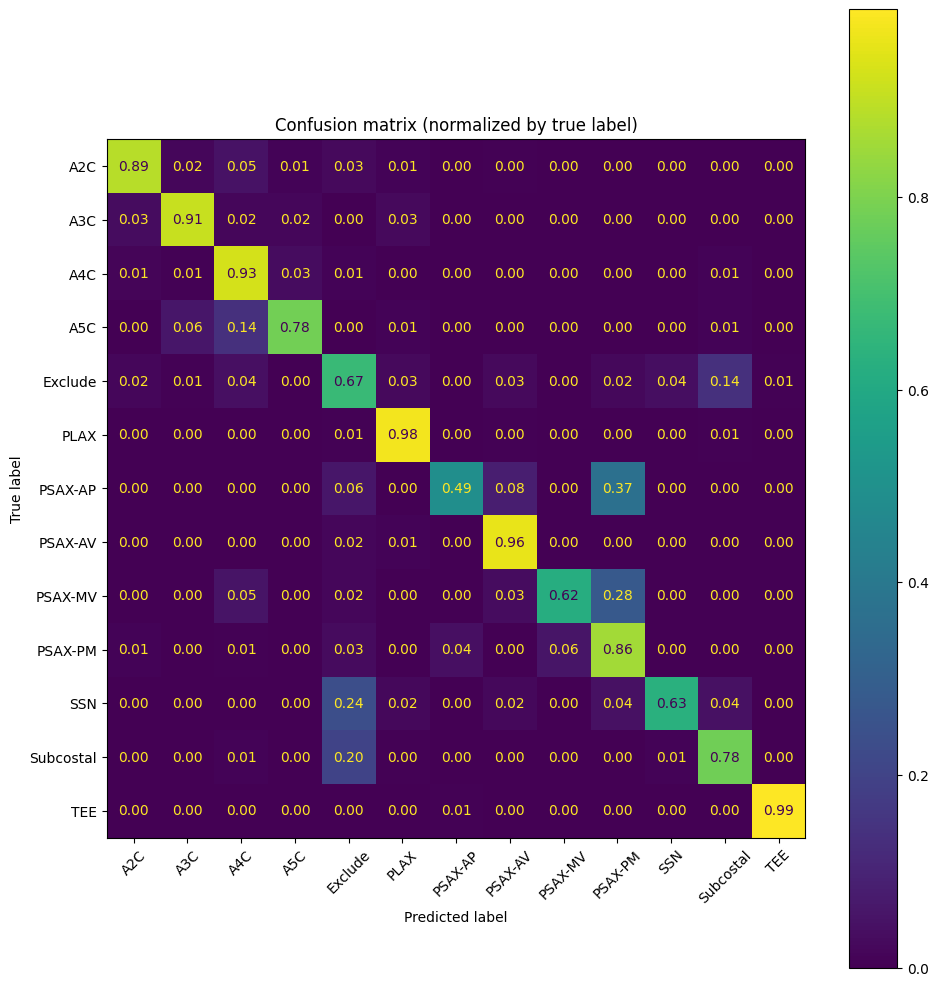

In [6]:
cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=label_names)
disp.plot(ax=ax, xticks_rotation=45, values_format=".2f")
ax.set_title("Confusion matrix (normalized by true label)")
plt.tight_layout()
plt.show()
